['Rank', 'NCT Number', 'Title', 'Acronym', 'Status', 'Study Results', 'Conditions', 'Interventions', 'Outcome Measures', 'Sponsor/Collaborators', 'Gender', 'Age', 'Phases', 'Enrollment', 'Funded Bys', 'Study Type', 'Study Designs', 'Other IDs', 'Start Date', 'Primary Completion Date', 'Completion Date', 'First Posted', 'Results First Posted', 'Last Update Posted', 'Locations', 'Study Documents', 'URL']


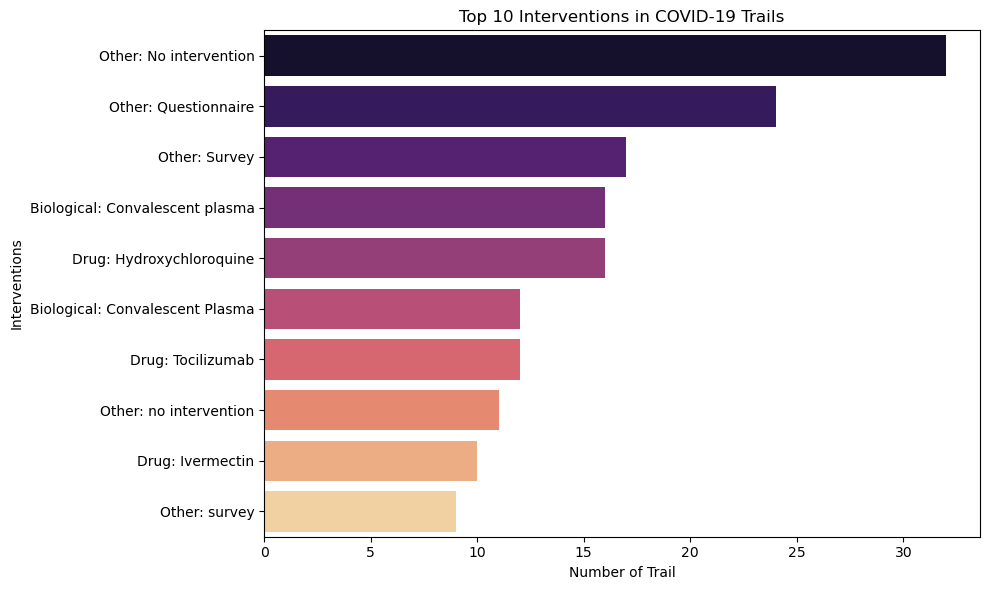

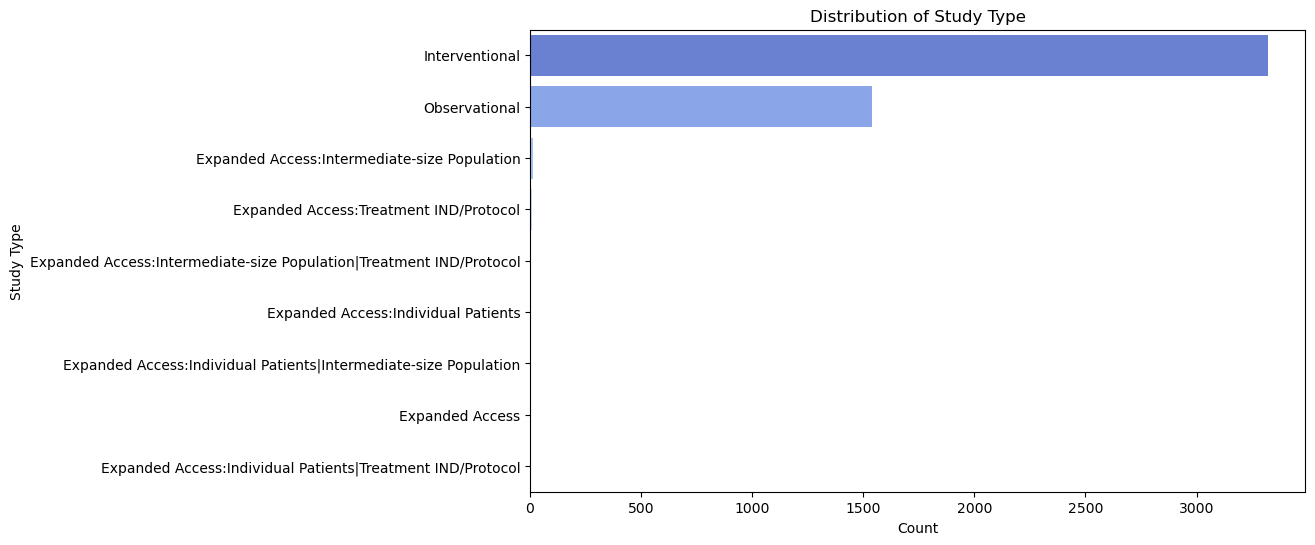

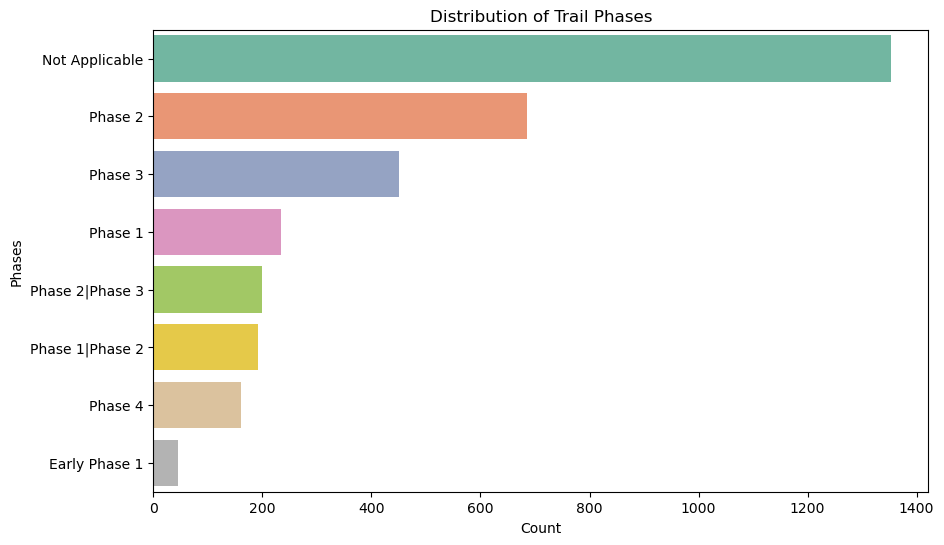

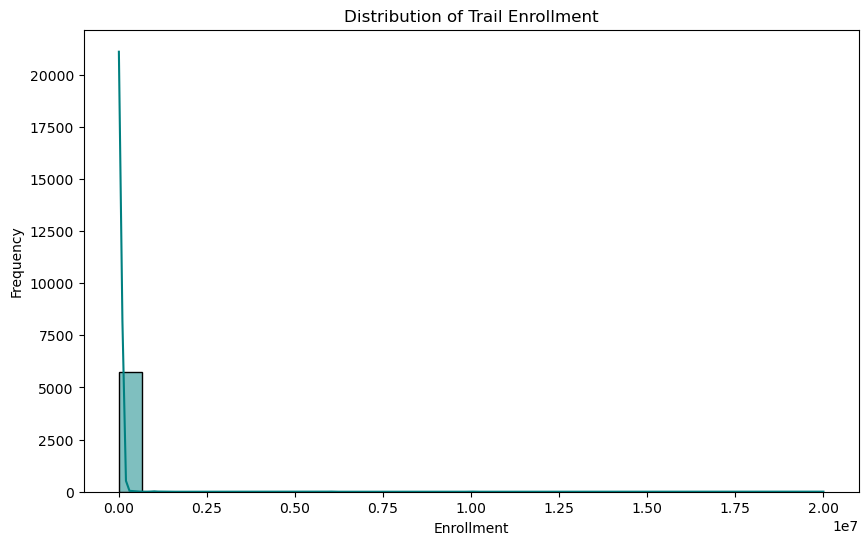

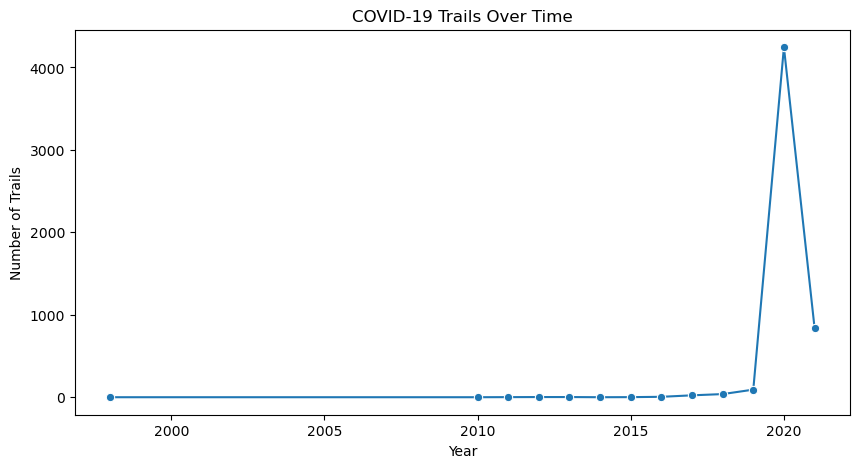

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('C:/Users/HP/Documents/DA_projects/covid/COVID_clinical_trials.csv')
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.isnull().sum()
df_clean=df.dropna(subset=['Study Type','Interventions'])
# top interventions
top_interventions=df_clean['Interventions'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_interventions.values,y=top_interventions.index, palette='magma')
plt.title('Top 10 Interventions in COVID-19 Trails')
plt.xlabel('Number of Trail')
plt.ylabel('Interventions')
plt.tight_layout()
plt.show()

# Study type distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, y ='Study Type', order=df_clean['Study Type'].value_counts().index, palette ='coolwarm')
plt.title('Distribution of Study Type')
plt.xlabel('Count')
plt.ylabel('Study Type')
plt.show()

# Trial phase distribution (if available)
if 'Phases' in df.columns:
    plt.figure(figsize=(10,6))
    sns.countplot(data=df_clean, y='Phases', order=df_clean['Phases'].value_counts().index, palette='Set2')
    plt.title('Distribution of Trail Phases')
    plt.xlabel('Count')
    plt.ylabel('Phases')
    plt.show()


# Enrollment size distribution
if 'Enrollment' in df.columns:
    df['Enrollment']=pd.to_numeric(df['Enrollment'], errors='coerce')
    plt.figure(figsize=(10,6))
    sns.histplot(df['Enrollment'].dropna(), bins=30,kde=True, color='teal')
    plt.title('Distribution of Trail Enrollment')
    plt.xlabel('Enrollment')
    plt.ylabel('Frequency')
    plt.show()

# Timeline of trials (if Start Date is available)
if 'Start Date' in df.columns:
    df['Start Date']=pd.to_datetime(df['Start Date'], errors='coerce')
    df['Year']=df['Start Date'].dt.year
    trails_by_year = df['Year'].value_counts().sort_index()
    plt.figure(figsize=(10,5))
    sns.lineplot(x=trails_by_year.index, y=trails_by_year.values, marker='o')
    plt.title('COVID-19 Trails Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Trails')
    plt.show()
    